In [1]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

2024-10-10 07:41:41.921378: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-10 07:42:02.366429: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [3]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [4]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [5]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [6]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [7]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [8]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.5616e-02,  3.5865e-02,  2.2708e-02, -6.0919e-02,  1.1478e-01,
         -5.7976e-02,  1.5329e-01, -5.8544e-02,  3.1236e-01,  7.9226e-03,
         -1.5723e-01,  7.3637e-02,  5.1356e-03, -8.6245e-02, -1.9665e-01,
         -4.6060e-03, -2.4553e-02,  2.6134e-03,  8.7952e-05, -1.6012e-01,
         -3.5422e-02,  1.2097e-01,  7.3860e-02, -1.3997e-01,  1.7250e-02,
          2.4613e-02, -6.1222e-02,  1.6407e-01, -3.2518e-01,  1.7116e-01,
         -3.1727e-02, -1.1589e-01,  4.7401e-03, -1.2909e-01,  7.1675e-02,
         -4.0509e-02, -7.7566e-02,  5.2777e-02, -4.0029e-03,  1.4338e-01,
         -6.6134e-02,  1.6166e-02,  4.7563e-02, -3.2336e-02, -4.8085e-02,
         -1.2039e-01, -1.2067e-01,  5.8204e-02, -6.6188e-03,  2.4483e-03,
          1.2473e-02,  7.1323e-02, -2.3756e-02, -1.6651e-01,  1.5828e-02,
          4.1388e-02, -8.7087e-02,  7.0760e-04, -6.4389e-02, -2.5253e-04,
         -3.3731e-02,  6.5148e-03,  1.2479e-01, -9.7723e-02]]), 'conv2': tensor([[-0.0645, -0.0451,  0

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0276,  0.0798,  0.1924,  0.1729, -0.0075,  0.1216,  0.0237,  0.1757,
          0.1126, -0.0739, -0.0710, -0.0031, -0.0275, -0.0070,  0.0217, -0.0237,
          0.0092,  0.0541, -0.0590,  0.0186, -0.1923, -0.0211,  0.1099,  0.0057,
         -0.0199, -0.0091,  0.1507,  0.0507, -0.0247,  0.0169,  0.0005,  0.1497,
          0.0133,  0.0581,  0.1614, -0.0114, -0.0009, -0.0009, -0.0342,  0.0246,
         -0.0813, -0.0117,  0.0851, -0.1581, -0.0043, -0.2818,  0.1122,  0.0074,
          0.1568,  0.0783, -0.0099,  0.0165,  0.0343,  0.1089, -0.0192,  0.1614,
         -0.0093,  0.1375,  0.0141,  0.0689,  0.1716, -0.0262,  0.0517,  0.0913]]), 'conv2': tensor([[-0.1885,  0.1674,  0.1749, -0.1000,  0.0770,  0.1459,  0.2849,  0.1932,
         -0.0510,  0.0812, -0.1993, -0.2232,  0.1412, -0.2686, -0.2893, -0.2965,
         -0.2149, -0.1909, -0.0599, -0.2064, -0.1401,  0.1115,  0.1477, -0.0557,
          0.1658,  0.2561,  0.1316, -0.1155, -0.1595, -0.1507,  0.1499,  0.1483]]), 'co

# EGG

## Helper Functions

In [13]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [14]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(100):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [15]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [16]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [17]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [18]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0346, 0.0478)
Baseline % GED to 1
(0.0887, 0.0943)
Baseline % GED to 0
(0.0702, 0.0802)
Epoch: 0 Losses:[2.488895123655146, -0.4473442144014619, 11162.256525213068, 2.65591363473372]
Epoch: 1 Losses:[1.340707172047008, -1.2012388760393315, 2753.49228737571, 2.733023903586648]
Epoch: 2 Losses:[0.9785757444121621, -1.4791966568339954, 978.0283203125, 2.8185844638130884]
Epoch: 3 Losses:[0.9173113812099803, -1.5128271579742432, 351.09123091264206, 2.885379520329562]
Epoch: 4 Losses:[0.7175553278489546, -1.651883981444619, 138.54645954478872, 2.924362204291604]
Epoch: 5 Losses:[0.7866713783957742, -1.615212158723311, 54.05635486949574, 2.9851726943796333]
Epoch: 6 Losses:[0.648259395902807, -1.7099301056428389, 21.848098494789816, 2.9756170294501563]
Epoch: 7 Losses:[0.5527356456626545, -1.7755876129323787, 9.9647536277771, 2.986365870995955]
Epoch: 8 Losses:[0.5462479130788283, -1.783873124556108, 5.354431455785578, 2.988202311775901]
Epoch: 9 Losses:[0.5

In [19]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8713, 0.8954)
Baseline % GED to 1
(0.0821, 0.0883)
Baseline % GED to 0
(0.0639, 0.0752)
Epoch: 0 Losses:[0.42479043115269055, -1.8480558612129905, 12843.2998046875, -2.6894952709024604]
Epoch: 1 Losses:[0.44191562045704236, -1.8402128544720737, 2039.1238347833807, -2.7953093485398726]
Epoch: 2 Losses:[0.40860533714294434, -1.85999549518932, 679.1914312189275, -2.868347644805908]
Epoch: 3 Losses:[0.404980022798885, -1.8659918199885974, 264.710654518821, -2.8981691815636377]
Epoch: 4 Losses:[0.38720365275036206, -1.8730974739248103, 111.45128562233664, -2.934779340570623]
Epoch: 5 Losses:[0.3882371105931022, -1.878071817484769, 49.623387423428625, -2.914861863309687]
Epoch: 6 Losses:[0.4031667546792464, -1.8670367219231345, 23.39572594382546, -2.963583902879195]
Epoch: 7 Losses:[0.41161328283223236, -1.8580020557750354, 11.786694353277033, -2.9656284288926558]
Epoch: 8 Losses:[0.41434432701631024, -1.8579390157352795, 6.581091490658847, -2.96557141434062

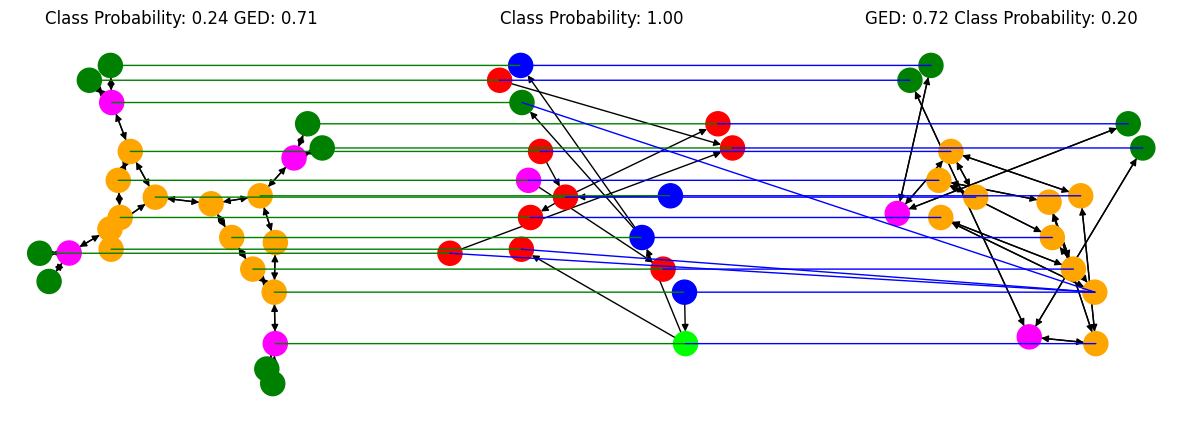

In [ ]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0129, 0.0181)
Baseline % GED to 1
(0.0796, 0.0849)
Baseline % GED to 0
(0.0613, 0.0704)
Epoch: 0 Losses:[3.0175610889088023, -0.08780327947302298, 12797.25106534091, 2.7402803518555383]
Epoch: 1 Losses:[2.936628883535212, -0.09708808836611835, 2190.2971635298295, 2.8294097726995293]
Epoch: 2 Losses:[3.071379444815896, -0.06439575790004297, 648.1366937810725, 2.910991917956959]
Epoch: 3 Losses:[3.06956748528914, -0.06620892645283179, 236.4178466796875, 3.007252964106473]
Epoch: 4 Losses:[3.1082442457025703, -0.050454282286492264, 97.46385886452414, 2.970422213727778]
Epoch: 5 Losses:[3.118905544281006, -0.050152832134203476, 42.45570755004883, 2.9446827173233032]
Epoch: 6 Losses:[3.116253527727994, -0.04966396161101081, 19.530059467662465, 3.030665636062622]
Epoch: 7 Losses:[3.098638664592396, -0.05600349334153262, 9.973875045776367, 2.9102654565464365]
Epoch: 8 Losses:[3.115984071384777, -0.05095022070136937, 5.813715761358088, 2.9992524710568516]
Epoc

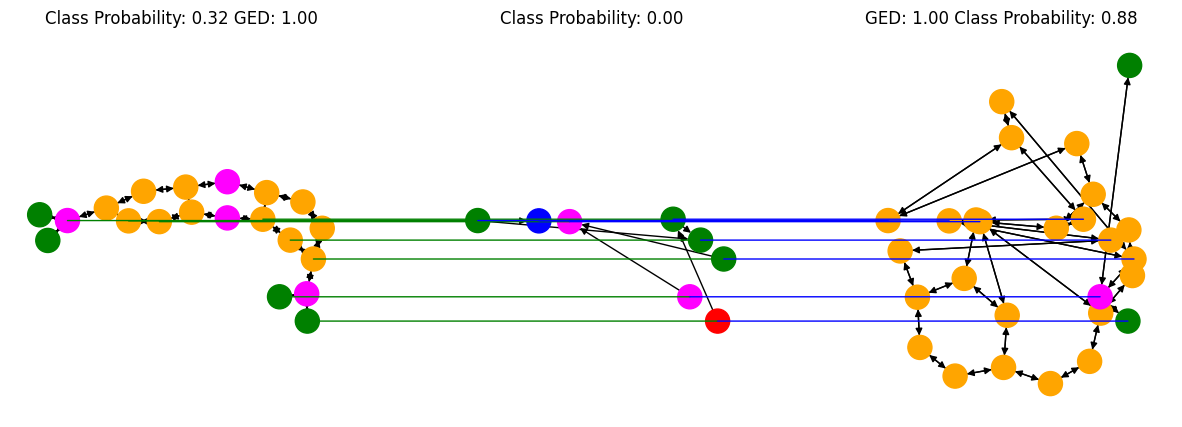

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9934, 0.9959)
Baseline % GED to 1
(0.0759, 0.0796)
Baseline % GED to 0
(0.0646, 0.0703)
Epoch: 0 Losses:[0.38911751183596527, -1.85748751596971, 11917.831853693182, -2.453559561209245]
Epoch: 1 Losses:[0.3775087703358043, -1.8685158382762561, 2024.5123512961648, -2.6376064257188276]
Epoch: 2 Losses:[0.3763391673564911, -1.8664510466835715, 654.2056857022372, -2.687114168297161]
Epoch: 3 Losses:[0.37503002990375867, -1.8643645156513562, 251.3163396661932, -2.685375609181144]
Epoch: 4 Losses:[0.3751704692840576, -1.8643461249091409, 105.56866524436258, -2.7055310119282114]
Epoch: 5 Losses:[0.3745957748456435, -1.8620158650658347, 45.48205375671387, -2.6277991316535254]
Epoch: 6 Losses:[0.3738149946386164, -1.859885660084811, 20.465584234757856, -2.6377242586829444]
Epoch: 7 Losses:[0.3733736412091689, -1.8573622920296409, 10.071417375044389, -2.5708750052885576]
Epoch: 8 Losses:[0.3770637864416296, -1.8513839678330855, 5.654746922579679, -2.6194951967759

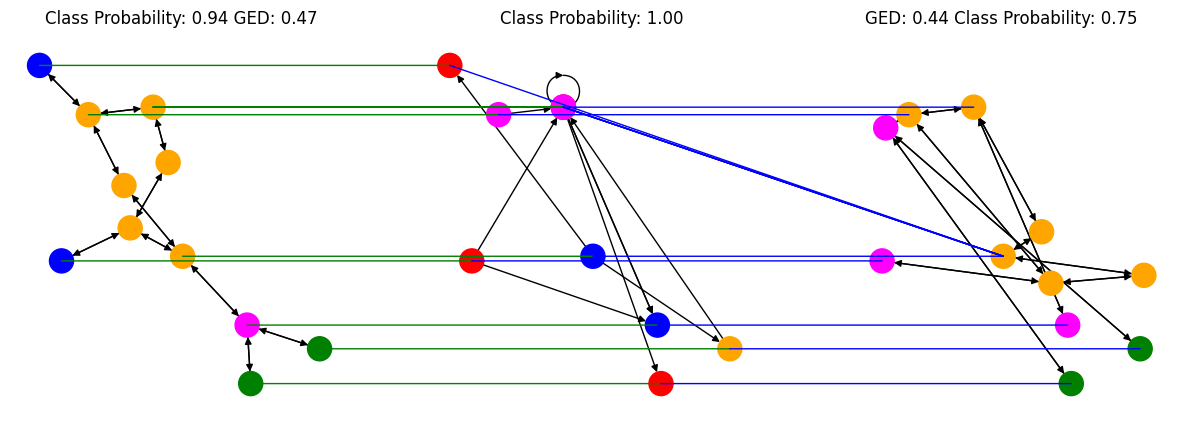

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [ ]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0241, 0.0338)
Baseline % GED to 1
(0.0879, 0.0904)
Baseline % GED to 0
(0.0674, 0.0789)
Epoch: 0 Losses:[2.0305545113303443, -0.35848177258263936, 11550.958984375, 2.6273225112394853]
Epoch: 1 Losses:[1.3593756610696965, -1.024505165490237, 2053.38388893821, 2.768271408297799]
Epoch: 2 Losses:[1.2621740753000432, -1.1732308972965588, 686.1885431463069, 2.811999104239724]
Epoch: 3 Losses:[1.0999961387027393, -1.34849581935189, 259.6249250932173, 2.82036554813385]
Epoch: 4 Losses:[1.021425799889998, -1.4688816558231006, 104.93780656294389, 2.865321782502261]
Epoch: 5 Losses:[0.958673818544908, -1.5492130517959595, 44.59920883178711, 2.8309875347397546]
Epoch: 6 Losses:[0.9053146026351235, -1.6075870665636929, 19.988472158258613, 2.8384798710996453]
Epoch: 7 Losses:[0.8769942738793113, -1.6526891751722856, 9.856182141737504, 2.813514546914534]
Epoch: 8 Losses:[0.9110327200456099, -1.6105402924797751, 5.536494298414751, 2.8924298828298394]
Epoch: 9 Losses:

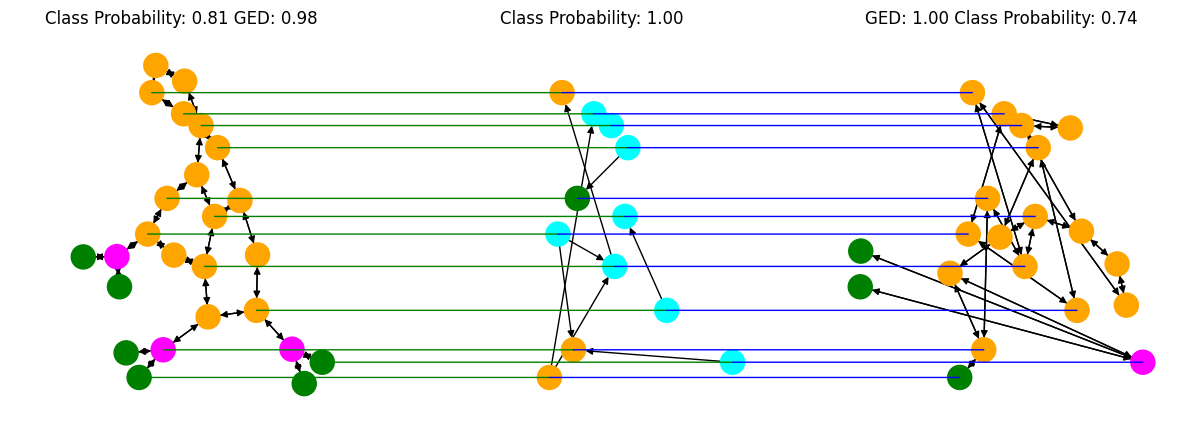

In [ ]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8222, 0.8527)
Baseline % GED to 1
(0.0839, 0.0882)
Baseline % GED to 0
(0.0655, 0.0746)
Epoch: 0 Losses:[0.755022639578039, -1.7970172817056829, 12304.745716441761, -2.64108669757843]
Epoch: 1 Losses:[0.717858840118755, -1.805950023911216, 2024.8675315163352, -2.7086980126120825]
Epoch: 2 Losses:[0.7172624143687162, -1.8289897008375688, 636.4301286177201, -2.7701369524002075]
Epoch: 3 Losses:[0.6890694878318093, -1.8302632136778398, 245.0344099564986, -2.7878358255733144]
Epoch: 4 Losses:[0.7078952789306641, -1.8058485876430164, 104.92473602294922, -2.817828969521956]
Epoch: 5 Losses:[0.678608856417916, -1.8264108354395086, 47.40710241144354, -2.767844460227273]
Epoch: 6 Losses:[0.6775304187427867, -1.800787177952853, 22.748289108276367, -2.7064923644065857]
Epoch: 7 Losses:[0.675858508456837, -1.809559085152366, 11.451661543412643, -2.7550159855322405]
Epoch: 8 Losses:[0.6618719859556719, -1.8302528316324407, 6.278430938720703, -2.7129420692270454]
Ep

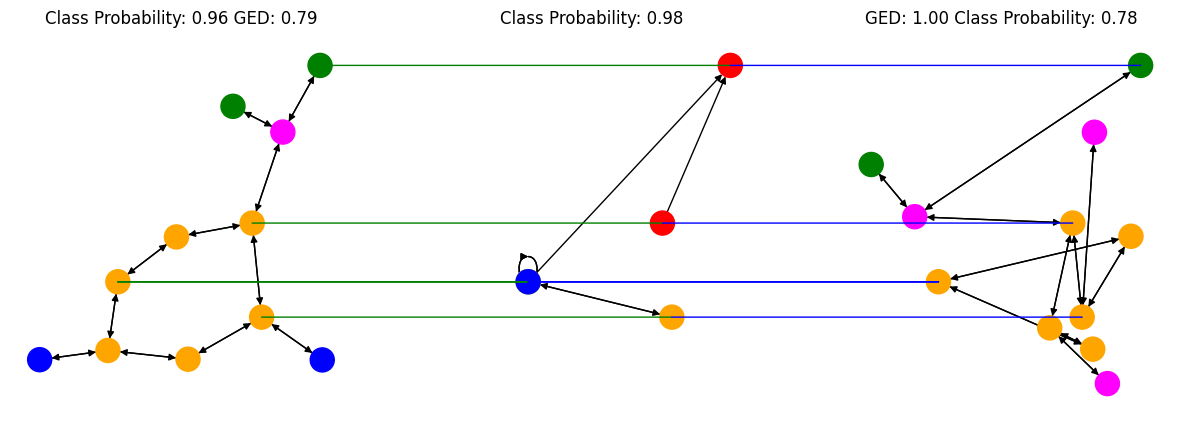

In [ ]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0002, 0.0004)
Baseline % GED to 1
(0.0781, 0.0829)
Baseline % GED to 0
(0.0612, 0.0704)
Epoch: 0 Losses:[2.345576828176325, -0.06410373476418582, 12535.546209161932, 2.5518745454874905]
Epoch: 1 Losses:[2.1838893456892534, -0.057480582798069176, 2066.579012784091, 2.42166499116204]
Epoch: 2 Losses:[1.901918422092091, -0.1397350372915918, 643.779316295277, 2.369929936799136]
Epoch: 3 Losses:[1.4943993850187822, -0.3957670710303567, 244.07222123579547, 2.274680023843592]
Epoch: 4 Losses:[1.095025203444741, -0.9028023020787672, 104.91156352650036, 2.278183303096078]
Epoch: 5 Losses:[0.9470405036752875, -1.1376325325532393, 46.0539699901234, 2.2909161881967024]
Epoch: 6 Losses:[0.8994536399841309, -1.1970976428552107, 21.24411747672341, 2.2460318966345354]
Epoch: 7 Losses:[0.8787788911299272, -1.2676390517841687, 10.56449573690241, 2.264189774339849]
Epoch: 8 Losses:[0.8144865144382823, -1.3437977162274448, 5.903949997641823, 2.2084678574041887]
Epoch: 9 L

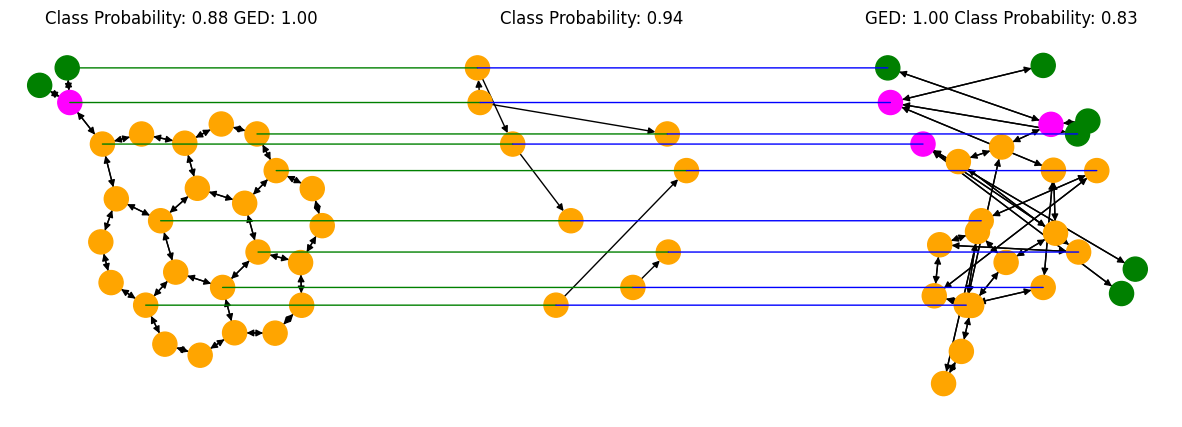

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9563, 0.9662)
Baseline % GED to 1
(0.0741, 0.077)
Baseline % GED to 0
(0.0624, 0.0717)
Epoch: 0 Losses:[0.5712251392277804, -1.8560224338011309, 11928.357044566761, -2.356638079339808]
Epoch: 1 Losses:[0.5078520720655267, -1.8569539785385132, 1877.9445856267755, -2.342178854075345]
Epoch: 2 Losses:[0.4792582094669342, -1.8352608572353015, 582.0688726251775, -2.319851913235404]
Epoch: 3 Losses:[0.46750084920362994, -1.8280541896820068, 217.63316761363637, -2.2982022762298584]
Epoch: 4 Losses:[0.48157195069573144, -1.8019579540599475, 90.10934101451527, -2.318233912641352]
Epoch: 5 Losses:[0.4957964447411624, -1.7630155194889416, 39.855727282437414, -2.293197138742967]
Epoch: 6 Losses:[0.49214177510955115, -1.7901507832787253, 18.39830103787509, -2.406227697025646]
Epoch: 7 Losses:[0.4921714500947432, -1.8031648939306086, 9.200466589494185, -2.4259152195670386]
Epoch: 8 Losses:[0.49610677090558136, -1.7769446806474165, 5.330169027501887, -2.3946815512397

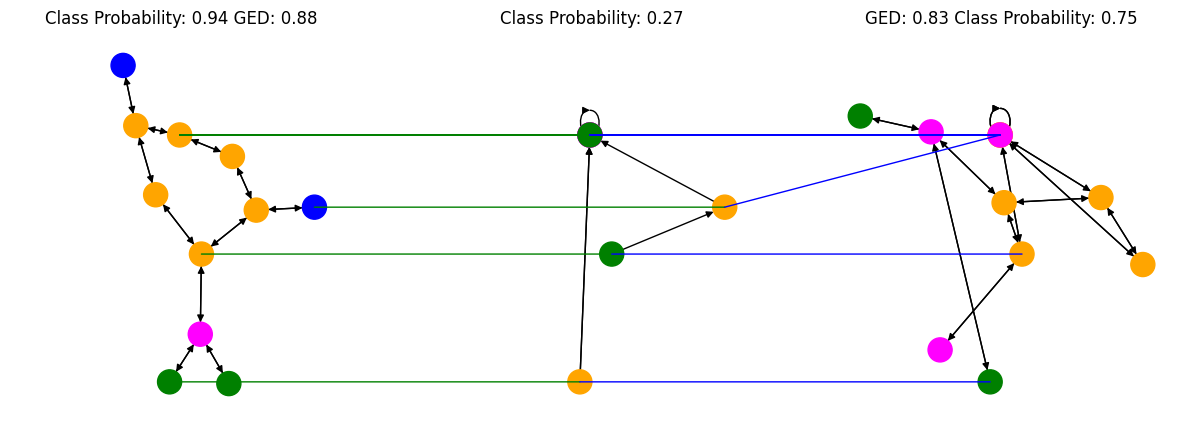

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [ ]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0598, 0.0759)
Baseline % GED to 1
(0.0891, 0.0938)
Baseline % GED to 0
(0.0683, 0.0817)
Epoch: 0 Losses:[1.8892300887541338, -0.5148877555673773, 11645.341930042614, 2.678863996809179]
Epoch: 1 Losses:[1.282543269070712, -0.8057858889753168, 2543.566328568892, 2.7890135808424517]
Epoch: 2 Losses:[1.1931790926239707, -0.8692481788721952, 751.3329051624645, 2.8813964128494263]
Epoch: 3 Losses:[1.0518985336477107, -0.9484716328707609, 281.3571888316761, 2.90068918466568]
Epoch: 4 Losses:[0.9517609747973356, -1.0157159946181558, 113.2543119950728, 2.9718710400841455]
Epoch: 5 Losses:[0.9334931427782233, -1.04476768320257, 46.20780476656827, 3.032555655999617]
Epoch: 6 Losses:[0.8693504441868175, -1.086307948285883, 20.89319896697998, 2.9430047382007944]
Epoch: 7 Losses:[0.8676297989758578, -1.0989394946531816, 9.90745175968517, 3.0158014839345757]
Epoch: 8 Losses:[0.8416132276708429, -1.112132354216142, 5.370940208435059, 3.0361637744036587]
Epoch: 9 Losse

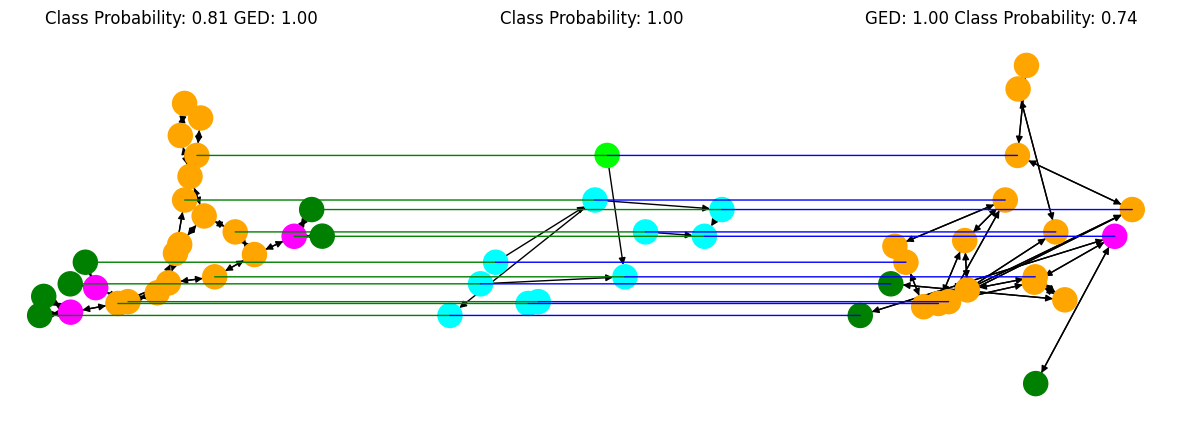

In [ ]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9383, 0.9525)
Baseline % GED to 1
(0.0785, 0.0811)
Baseline % GED to 0
(0.0607, 0.07)
Epoch: 0 Losses:[0.7150540568611838, -1.1215587746013294, 14497.449440696022, -2.6202832568775523]
Epoch: 1 Losses:[0.7488194270567461, -1.1451895020224832, 2471.4726118607955, -2.805426299571991]
Epoch: 2 Losses:[0.7399034987796437, -1.175288438796997, 774.0691639293324, -2.891998540271412]
Epoch: 3 Losses:[0.7315760146487843, -1.184582688591697, 286.6827572909269, -2.9156329089945014]
Epoch: 4 Losses:[0.7447981455109336, -1.193239992315119, 117.37164861505681, -2.9127201817252417]
Epoch: 5 Losses:[0.7547398643060164, -1.1998860402540727, 51.75772614912553, -3.0593468601053413]
Epoch: 6 Losses:[0.7461523359472101, -1.215773495760831, 24.1500977602872, -3.010411327535456]
Epoch: 7 Losses:[0.7469261234456842, -1.2182825695384631, 12.042777494950728, -3.010424169627103]
Epoch: 8 Losses:[0.7540232105688616, -1.222486225041476, 6.581281011754816, -3.0160258466547187]
Epoc

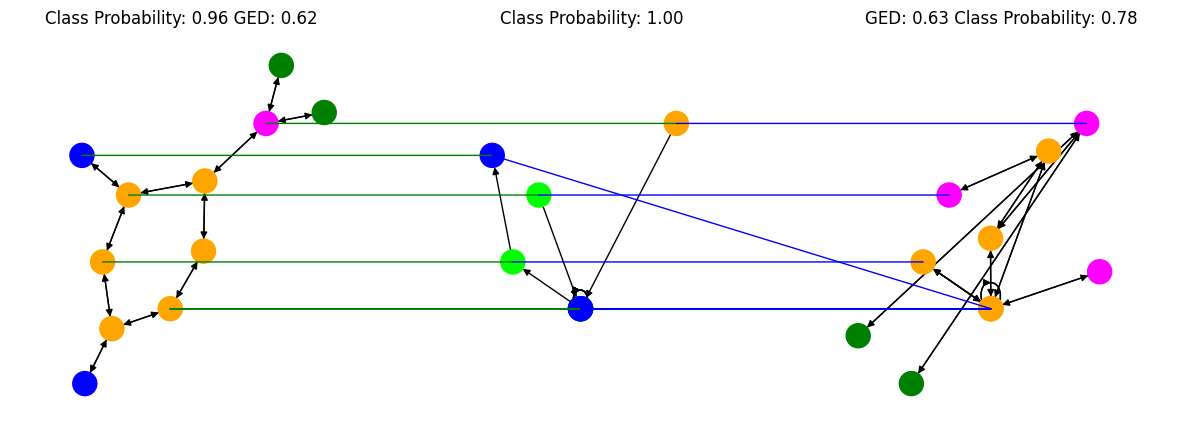

In [ ]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.002, 0.0038)
Baseline % GED to 1
(0.0768, 0.0826)
Baseline % GED to 0
(0.0606, 0.0684)
Epoch: 0 Losses:[2.3342250260439785, -0.22619327225468375, 11653.734752308239, 2.4390704577619378]
Epoch: 1 Losses:[2.1439014889977197, -0.13877637481147592, 1865.3970281427557, 2.3469293984499844]
Epoch: 2 Losses:[1.7625463984229348, -0.19006234068762173, 584.9173167835582, 2.18404498425397]
Epoch: 3 Losses:[1.1961213892156428, -0.421790439974178, 253.64819890802556, 2.1627075509591536]
Epoch: 4 Losses:[0.8885838497768749, -0.6243315718390725, 118.03390780362216, 2.153725055131045]
Epoch: 5 Losses:[0.8311812715096907, -0.6954125436869535, 53.56300943548029, 2.1505114923823965]
Epoch: 6 Losses:[0.7025153853676536, -0.7835083712231029, 24.90864406932484, 2.1985902190208435]
Epoch: 7 Losses:[0.6514120427044955, -0.8147030201825228, 12.451635534113104, 2.1895669915459375]
Epoch: 8 Losses:[0.6765391447327354, -0.8179914626208219, 6.698732852935791, 2.193600047718395]
Epo

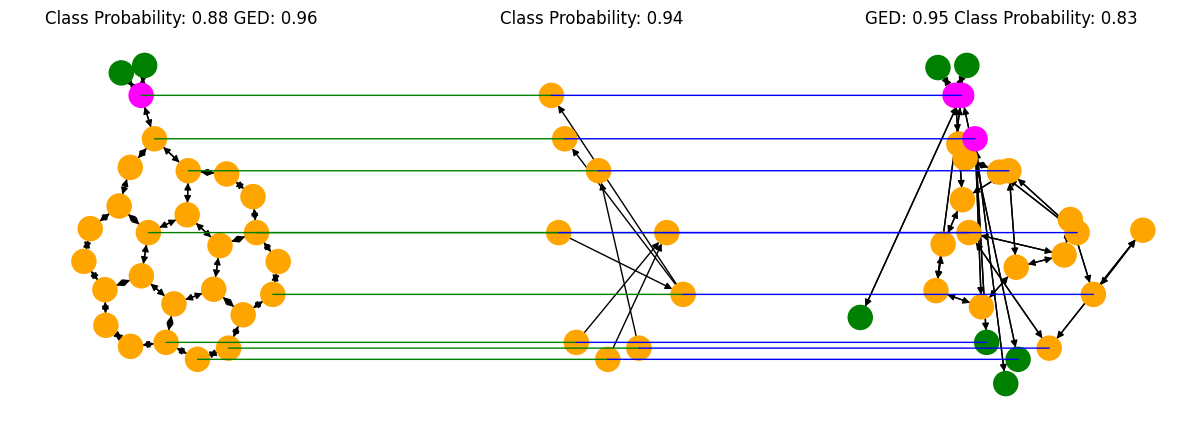

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9668, 0.9749)
Baseline % GED to 1
(0.0797, 0.0825)
Baseline % GED to 0
(0.0684, 0.0711)
Epoch: 0 Losses:[0.6006321094252847, -1.0955596186897971, 11737.380260120739, -2.590866121378812]
Epoch: 1 Losses:[0.6146283095533197, -1.1204218972813, 1878.1350929953835, -2.85218007998033]
Epoch: 2 Losses:[0.6293442791158502, -1.140025171366605, 568.7229697487571, -2.8883906386115332]
Epoch: 3 Losses:[0.6376962986859408, -1.1486943309957331, 206.17496837269175, -2.9306937889619307]
Epoch: 4 Losses:[0.636655103076588, -1.1483057954094626, 84.17499160766602, -2.9685181054201992]
Epoch: 5 Losses:[0.6388005126606334, -1.1509359858252786, 36.55091736533425, -3.0243418975309893]
Epoch: 6 Losses:[0.6485573866150596, -1.162030664357272, 16.577982902526855, -2.9948026592081245]
Epoch: 7 Losses:[0.6462808739055287, -1.158523364500566, 8.324814969843084, -2.9827230193398218]
Epoch: 8 Losses:[0.646733202717521, -1.1593731966885654, 4.85808177427812, -3.028367454355413]
Epoch

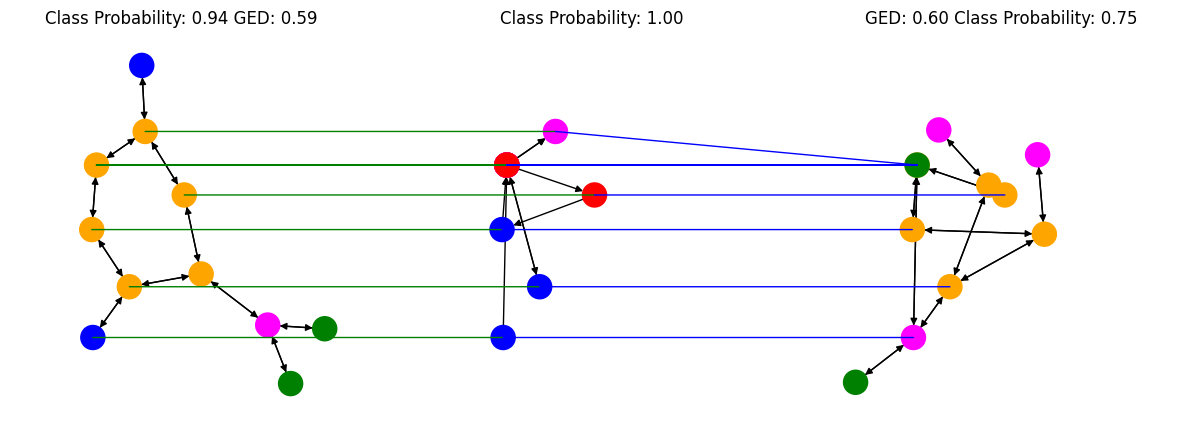

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [ ]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0285, 0.0419)
Baseline % GED to 1
(0.0844, 0.088)
Baseline % GED to 0
(0.0668, 0.075)
Epoch: 0 Losses:[2.3095973513343115, -0.3562924022024328, 14102.990056818182, 2.436692172830755]
Epoch: 1 Losses:[2.2605472694743765, -0.3184390230612321, 3279.7092063210225, 2.242752733555707]
Epoch: 2 Losses:[2.0293473330411045, -0.29518862068653107, 1541.8385786576705, 2.0539916211908515]
Epoch: 3 Losses:[1.940944563258778, -0.24657557904720306, 919.439619584517, 1.8655950129032135]
Epoch: 4 Losses:[1.900510397824374, -0.21176751364361157, 644.5643698952415, 1.7609272409569134]
Epoch: 5 Losses:[1.752358241514726, -0.23827253823930566, 462.9315157803622, 1.5783184387467124]
Epoch: 6 Losses:[1.6097010482441296, -0.25179352408105676, 356.4750615900213, 1.5554427341981367]
Epoch: 7 Losses:[1.4777593287554653, -0.2900147410956296, 285.9253040660511, 1.4687540991739794]
Epoch: 8 Losses:[1.4134186614643445, -0.2907680598172275, 250.0522322221236, 1.3900007768110796]
Epoch

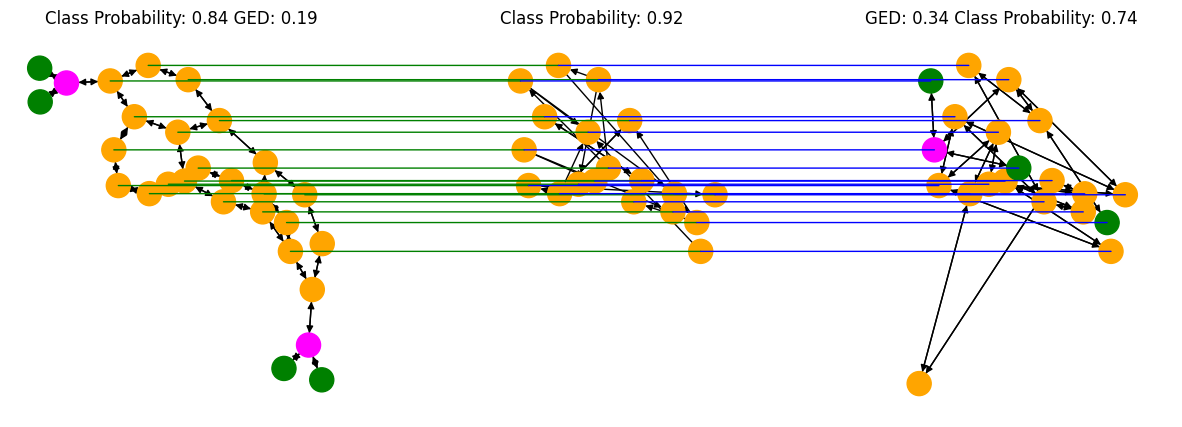

In [ ]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.8481, 0.8747)
Baseline % GED to 1
(0.0826, 0.0864)
Baseline % GED to 0
(0.0666, 0.0742)
Epoch: 0 Losses:[0.8925759954886003, -1.0432253154841336, 15438.072132457386, -2.8033522204919294]
Epoch: 1 Losses:[0.8503444790840149, -1.0861874439499595, 4553.260919744318, -2.8684483766555786]
Epoch: 2 Losses:[0.8450645370916887, -1.0905587131326848, 2431.4710582386365, -2.924793774431402]
Epoch: 3 Losses:[0.8732089129361239, -1.0792244185100903, 1401.4463223544035, -2.878721172159368]
Epoch: 4 Losses:[0.8144597519527782, -1.1035848747600208, 832.4886252663352, -2.957591403614391]
Epoch: 5 Losses:[0.8364708315242421, -1.1058254892175847, 518.0218478116122, -2.951091029427268]
Epoch: 6 Losses:[0.8378449190746654, -1.0894726406444202, 307.318115234375, -2.9597566669637505]
Epoch: 7 Losses:[0.8076256838711825, -1.1103564609180798, 192.63701282848012, -2.940612727945501]
Epoch: 8 Losses:[0.8455842245708812, -1.0951283465732227, 108.1915449662642, -2.910630453716625]

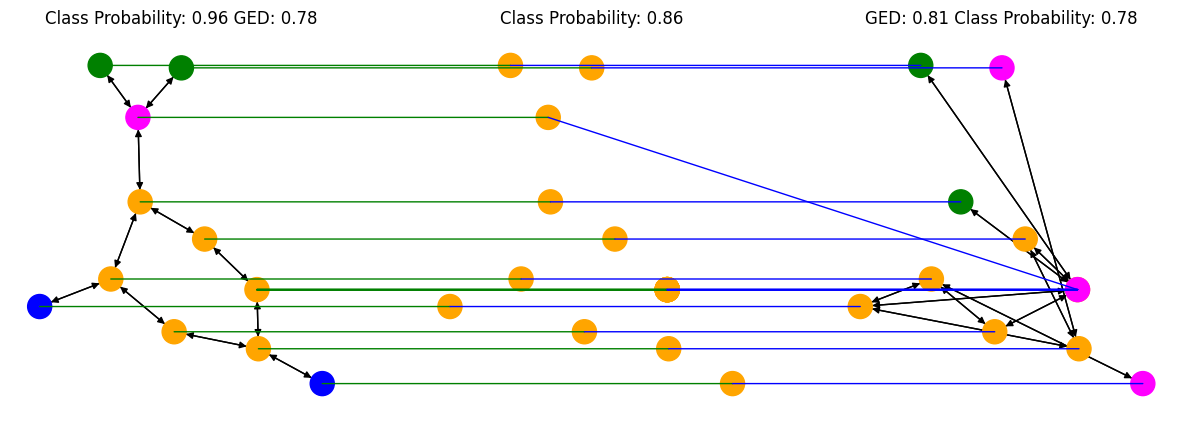

In [ ]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

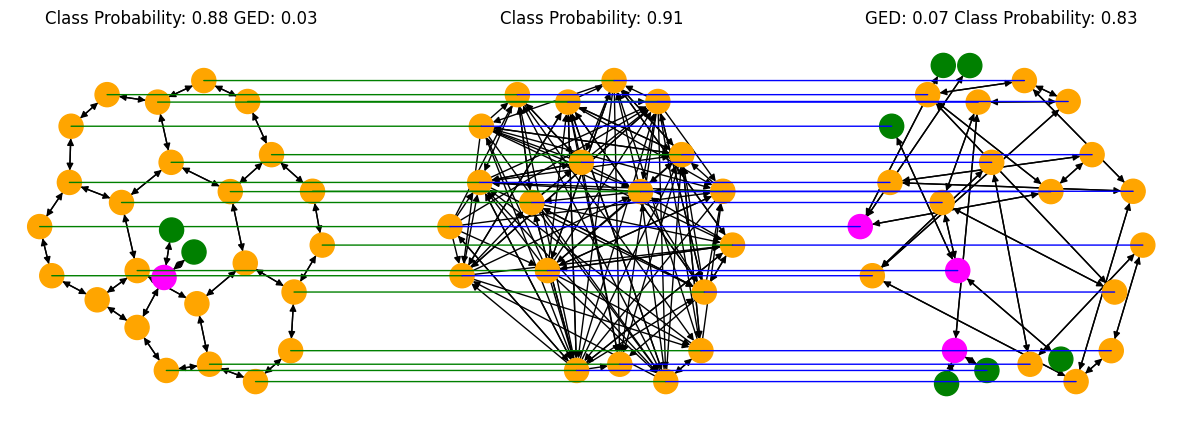

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9992, 0.9996)
Baseline % GED to 1
(0.0824, 0.0843)
Baseline % GED to 0
(0.0667, 0.0766)
Epoch: 0 Losses:[0.6420294154774059, -1.1544308987530796, 13470.168812144886, -2.785851153460416]
Epoch: 1 Losses:[0.6605870669538324, -1.1734348210421475, 3734.2470481178975, -2.979782754724676]
Epoch: 2 Losses:[0.6732941811734979, -1.1844275864687832, 1803.780195756392, -3.106279503215443]
Epoch: 3 Losses:[0.680470732125369, -1.1903142712332986, 962.9516490589489, -3.1317939975044946]
Epoch: 4 Losses:[0.6865533969619058, -1.1961892409758135, 549.721210826527, -3.125262672250921]
Epoch: 5 Losses:[0.6907204660502347, -1.1990704102949663, 315.7024397416548, -3.10044049132954]
Epoch: 6 Losses:[0.6951076984405518, -1.2017718770287253, 189.72297529740766, -3.1437395377592607]
Epoch: 7 Losses:[0.7010283307595686, -1.206970756704157, 107.8255282315341, -3.209746230732311]
Epoch: 8 Losses:[0.7028851292350076, -1.2070946910164573, 54.468901200727984, -3.1097642833536323]
Ep

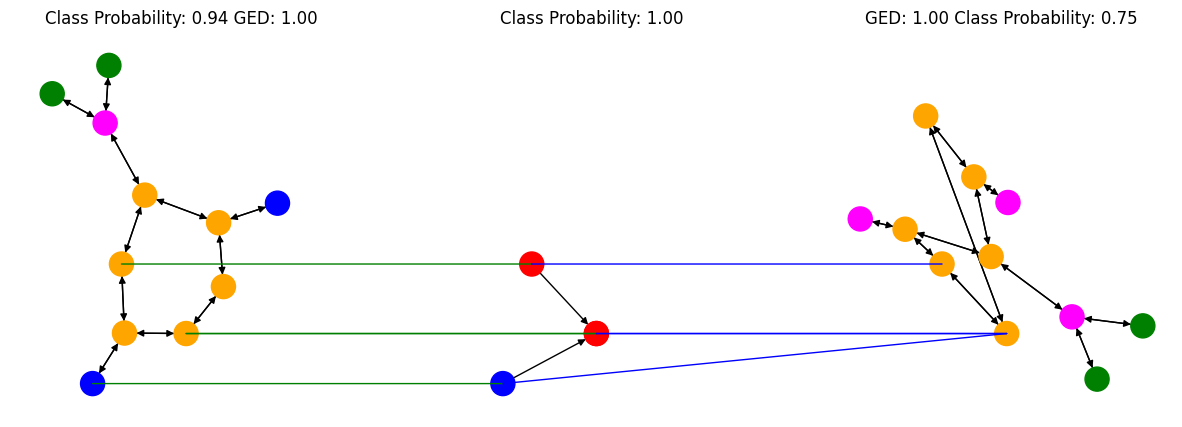

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [ ]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.1073, 0.1338)
Baseline % GED to 1
(0.086, 0.0899)
Baseline % GED to 0
(0.0667, 0.0778)
Epoch: 0 Losses:[1.5497633868997747, -0.6445240513844923, 21782.528586647728, 2.4092113104733555]
Epoch: 1 Losses:[0.9560478221286427, -0.9155097928914157, 15685.926047585228, 2.2534774216738613]
Epoch: 2 Losses:[0.7322235107421875, -1.0437701832164417, 14493.36709872159, 2.1132967986843805]
Epoch: 3 Losses:[0.7233857349915938, -1.0447092706506902, 14151.64737215909, 1.8822021972049365]
Epoch: 4 Losses:[0.7003464644605463, -1.0250663757324219, 13834.10848721591, 1.839245855808258]
Epoch: 5 Losses:[0.6620623523538763, -1.0365520824085583, 13829.282492897728, 1.7372593039816075]
Epoch: 6 Losses:[0.6618641073053534, -1.0100522149692883, 13798.218927556818, 1.6553832482207904]
Epoch: 7 Losses:[0.6320123509927229, -0.9955574599179354, 13709.592507102272, 1.5754286430098794]
Epoch: 8 Losses:[0.6062788800759749, -0.9863218448378823, 13463.8017578125, 1.4694582630287518]
Epo

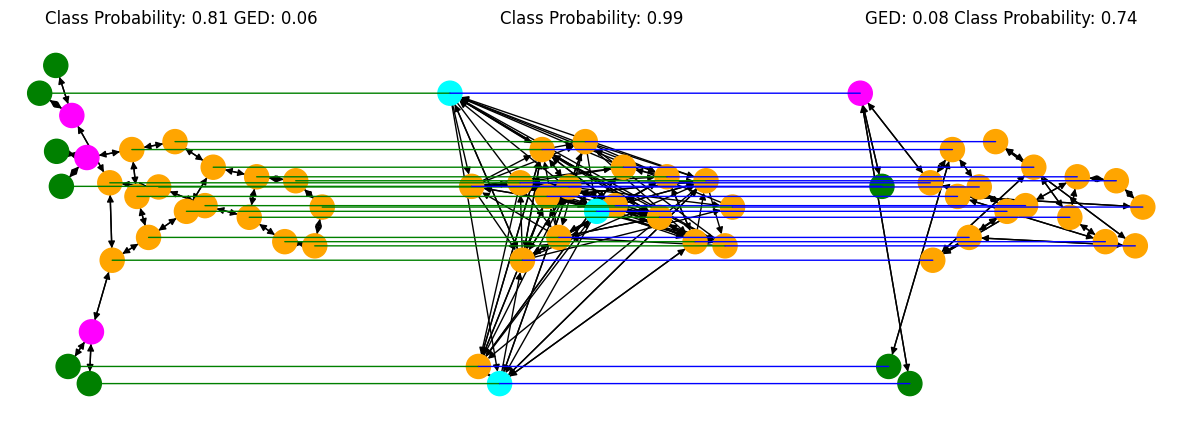

In [ ]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [ ]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.8952, 0.9153)
Baseline % GED to 1
(0.0824, 0.0855)
Baseline % GED to 0
(0.0669, 0.0734)
Epoch: 0 Losses:[0.7632681402293119, -1.139358726414767, 15205.279163707386, -2.7689707279205322]
Epoch: 1 Losses:[0.7563445784828879, -1.186336961659518, 3925.6213156960225, -2.8738469535654243]
Epoch: 2 Losses:[0.778686442158439, -1.1975432309237393, 1916.2563698508523, -2.9922671534798364]
Epoch: 3 Losses:[0.7953055988658558, -1.210767074064775, 1123.2404840642755, -2.987576723098755]
Epoch: 4 Losses:[0.7872639406811107, -1.2247351949865168, 670.4342762340199, -2.9669886393980547]
Epoch: 5 Losses:[0.7776799201965332, -1.23744168064811, 404.75028852982956, -2.952068101276051]
Epoch: 6 Losses:[0.7954393137585033, -1.2284987406297163, 267.5982402454723, -2.899359096180309]
Epoch: 7 Losses:[0.7940135381438516, -1.2422850240360608, 167.16571738503197, -2.9654491164467554]
Epoch: 8 Losses:[0.7903458746996793, -1.2416206815026023, 107.70147774436258, -2.9277173930948432

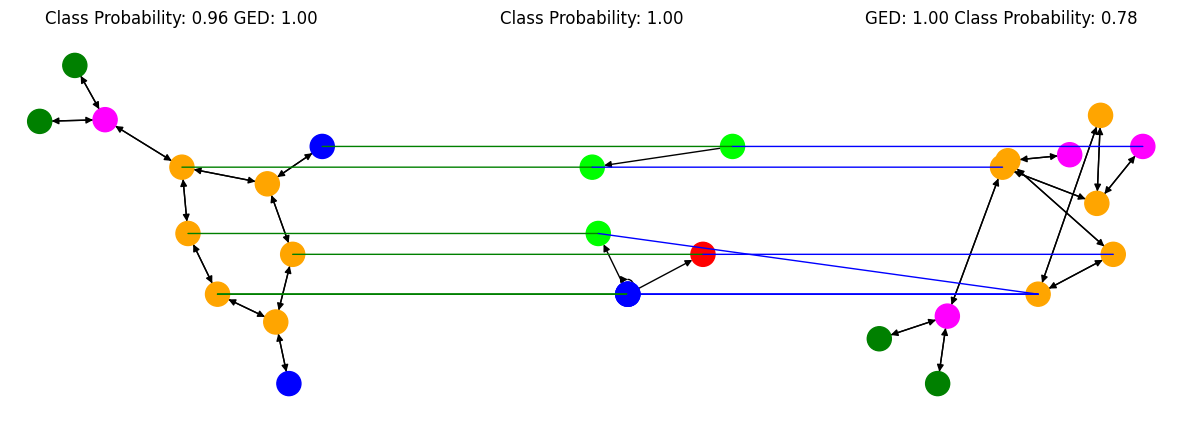

In [ ]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

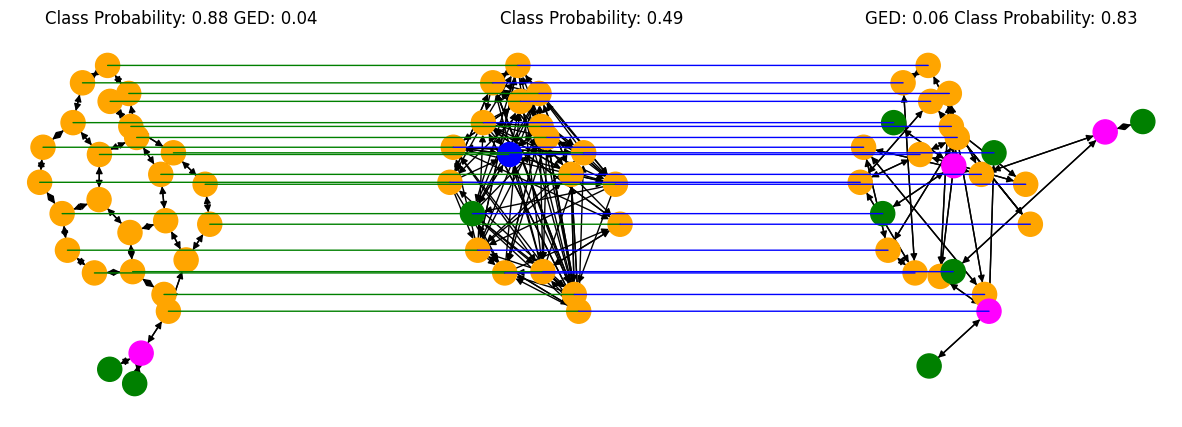

In [ ]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [ ]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9884, 0.9921)
Baseline % GED to 1
(0.0794, 0.0822)
Baseline % GED to 0
(0.0664, 0.0698)
Epoch: 0 Losses:[0.6217087398875843, -1.1357576196843928, 14620.8193359375, -2.7144043012098833]
Epoch: 1 Losses:[0.6401756460016425, -1.1570202654058284, 4294.768710049716, -3.0191417173905806]
Epoch: 2 Losses:[0.6467390927401456, -1.163257122039795, 2075.2388916015625, -3.0656265670602973]
Epoch: 3 Losses:[0.6549692479046908, -1.170789046721025, 1058.4116932262075, -3.0874790386720137]
Epoch: 4 Losses:[0.6572569229386069, -1.1720525459809736, 577.7509155273438, -3.1257104223424736]
Epoch: 5 Losses:[0.6602923544970426, -1.1745886477557095, 324.1438806707209, -3.1169128201224585]
Epoch: 6 Losses:[0.6674334406852722, -1.1803346330469304, 202.11054715243253, -3.141566124829379]
Epoch: 7 Losses:[0.6658508398316123, -1.1794909672303633, 119.54460213401101, -3.1274212165312334]
Epoch: 8 Losses:[0.6716013550758362, -1.1843985427509656, 64.62689590454102, -3.08929173512892

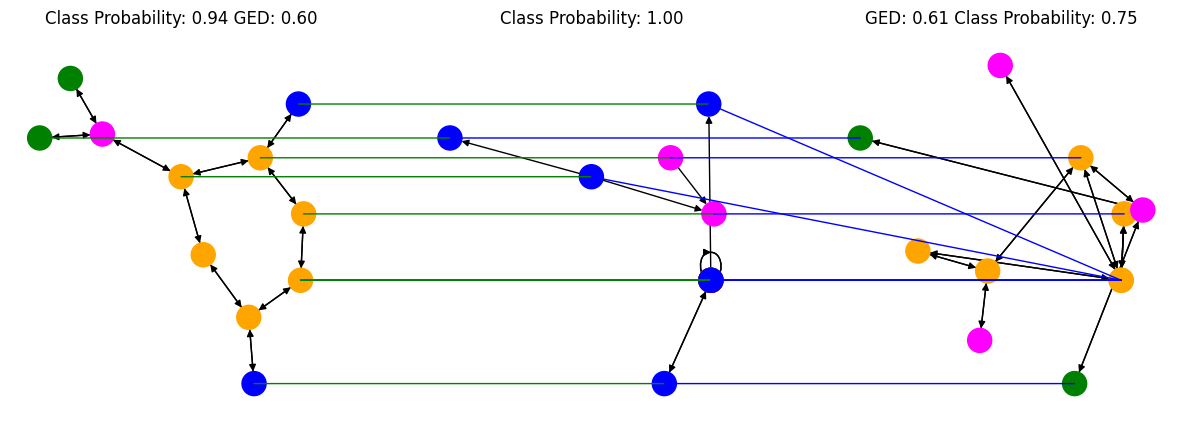

In [ ]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [ ]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

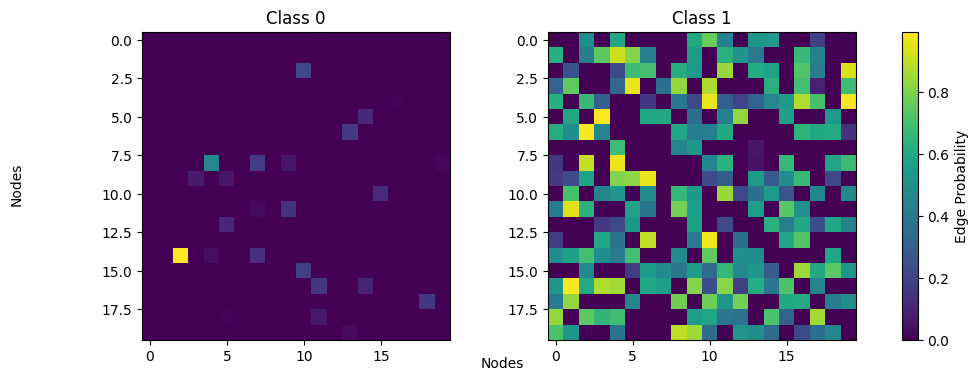

In [ ]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

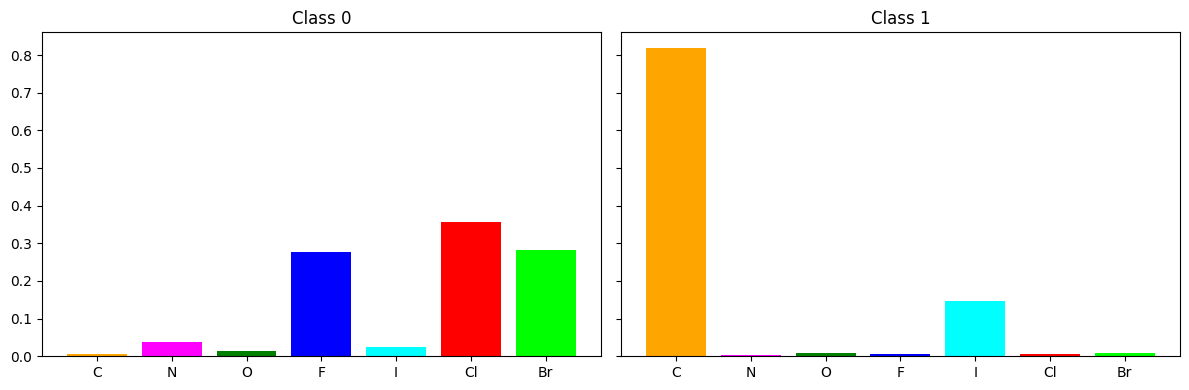

In [ ]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

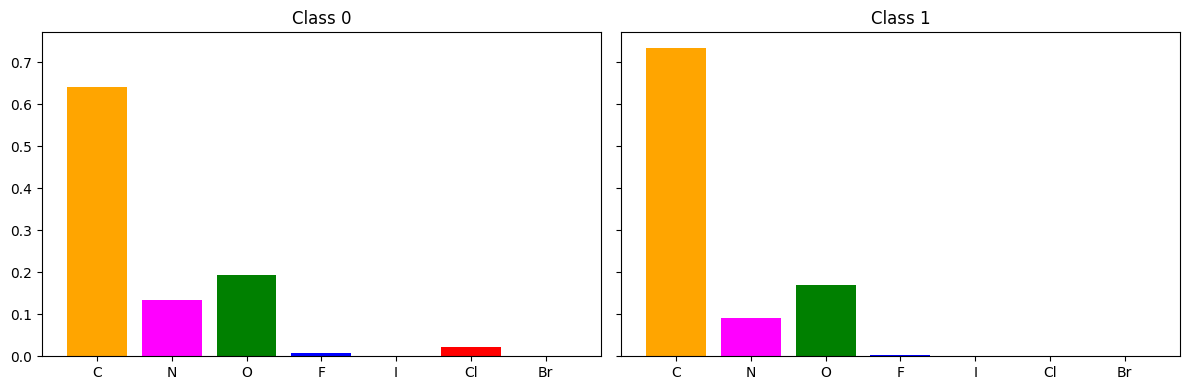

In [ ]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[0].bar(plot_indices, percentages_0, color=color_palette)
axes[1].bar(plot_indices, percentages_1, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

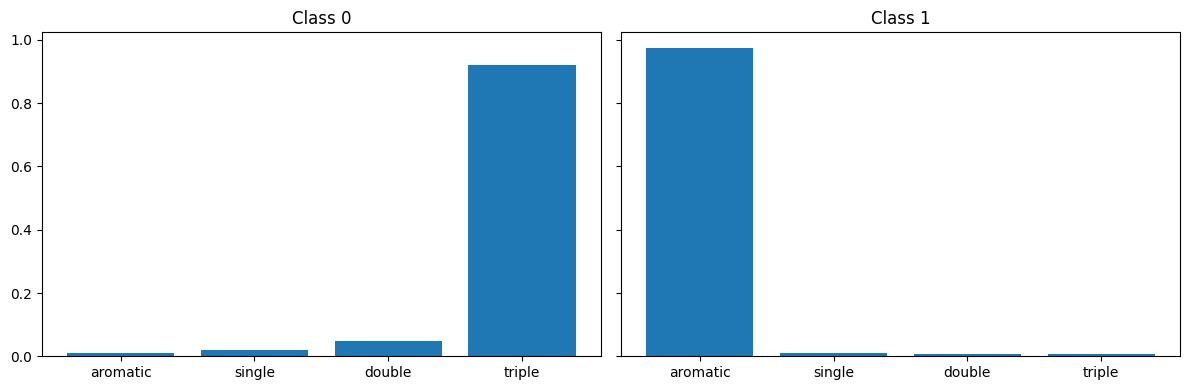

In [ ]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

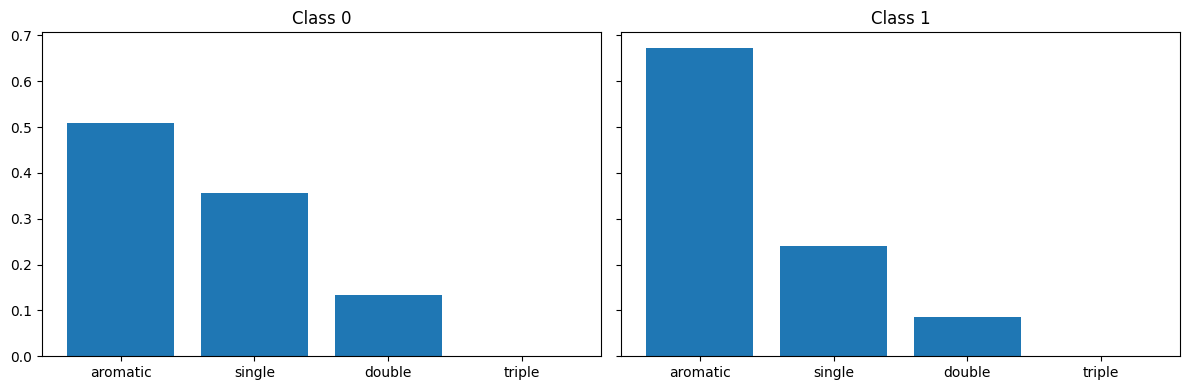

In [ ]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(edge_types, percentages_0)
axes[1].bar(edge_types, percentages_1)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

### Clean-UP

In [ ]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/work/DPDS/s224833/Dissertation/gnn-egg/env/egg-env-38/lib/python3.8/site-packages/torch/distributed/distributed_c10d.py:293: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(
